## **Batch Gradient Decent**

In [7]:
import numpy as np

# Sun'iy dataset
X = np.array([1, 2, 3, 4, 5])
y = np.array([3, 5, 7, 9, 11])  # aslida y = 2x + 1

# Parametrlar
w, b = 0.0, 0.0
lr = 0.02
epochs = 1000
m = len(X)

for epoch in range(epochs):
    # model prediction
    y_pred = w * X + b
    
    # loss gradientlari
    dw = (-2/m) * np.sum(X * (y - y_pred))
    db = (-2/m) * np.sum(y - y_pred)
    
    # yangilash
    w -= lr * dw
    b -= lr * db

print(f"Batch GD -> w: {w:.3f}, b: {b:.3f}")

Batch GD -> w: 2.000, b: 1.000


In [10]:
import numpy as np

class BatchGD:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.w = 0.0
        self.b = 0.0

    def fit(self, X, y):
        m = len(X)
        for epoch in range(self.epochs):
            y_pred = self.w * X + self.b
            dw = (-2/m) * np.sum(X * (y - y_pred))
            db = (-2/m) * np.sum(y - y_pred)
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

    def predict(self, X):
        return self.w * X + self.b

## **Stochastic Gradient Descent**

In [ ]:
w, b = 0.0, 0.0
lr = 0.01
epochs = 100

for epoch in range(epochs):
    for i in range(len(X)):
        xi, yi = X[i], y[i]
        y_pred = w * xi + b
        dw = -2 * xi * (yi - y_pred)
        db = -2 * (yi - y_pred)
        w -= lr * dw
        b -= lr * db

print(f"SGD -> w: {w:.3f}, b: {b:.3f}")

SGD -> w: 2.014, b: 0.941


In [8]:
import numpy as np

class StochasticGD:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.w = 0.0
        self.b = 0.0

    def fit(self, X, y):
        m = len(X)
        for epoch in range(self.epochs):
            for i in range(m):
                xi = X[i]
                yi = y[i]
                
                # model prediction
                y_pred = self.w * xi + self.b
                
                # loss gradientlari
                dw = -2 * xi * (yi - y_pred)
                db = -2 * (yi - y_pred)
                
                # yangilash
                self.w -= self.lr * dw
                self.b -= self.lr * db

    def predict(self, X):
        return self.w * X + self.b

## **Mini Batch Gradient Decent**

In [ ]:
w, b = 0.0, 0.0
lr = 0.01
epochs = 200
batch_size = 2
m = len(X)

for epoch in range(epochs):
    # tasodifiy aralashtirish
    indices = np.random.permutation(m)
    X_shuffled, y_shuffled = X[indices], y[indices]
    
    for i in range(0, m, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        y_pred = w * X_batch + b
        dw = (-2/len(X_batch)) * np.sum(X_batch * (y_batch - y_pred))
        db = (-2/len(X_batch)) * np.sum(y_batch - y_pred)
        
        w -= lr * dw
        b -= lr * db

print(f"Mini-batch GD -> w: {w:.3f}, b: {b:.3f}")

Mini-batch GD -> w: 2.013, b: 0.946


In [9]:
import numpy as np

class MiniBatchGD:
    def __init__(self, learning_rate=0.01, epochs=1000, batch_size=32):
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.w = 0.0
        self.b = 0.0

    def fit(self, X, y):
        m = len(X)
        for epoch in range(self.epochs):
            indices = np.random.permutation(m)
            X_shuffled, y_shuffled = X[indices], y[indices]
            
            for i in range(0, m, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]
                
                y_pred = self.w * X_batch + self.b
                dw = (-2/len(X_batch)) * np.sum(X_batch * (y_batch - y_pred))
                db = (-2/len(X_batch)) * np.sum(y_batch - y_pred)
                
                self.w -= self.lr * dw
                self.b -= self.lr * db

    def predict(self, X):
        return self.w * X + self.b

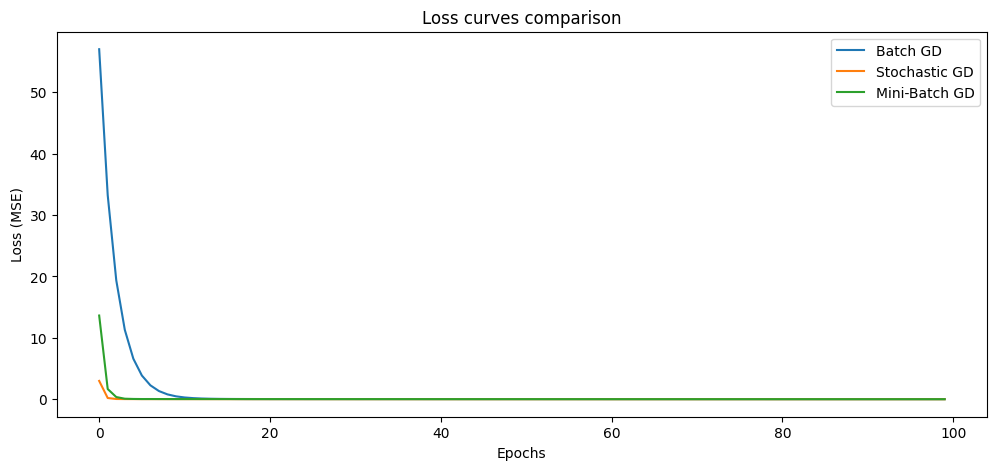

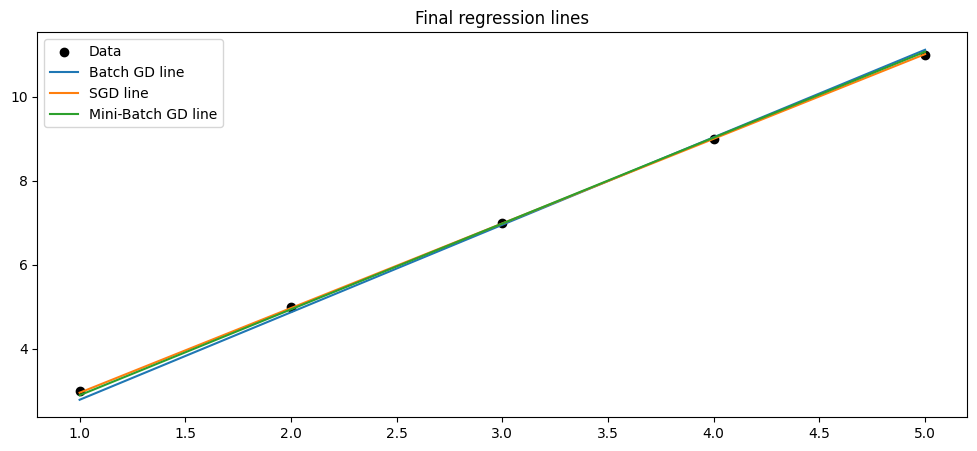

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --- Dataset ---
X = np.array([1, 2, 3, 4, 5])
y = np.array([3, 5, 7, 9, 11])  # aslida y = 2x + 1

# Klasslarga kichik o'zgartirish (loss saqlash uchun)
class BatchGD:
    def __init__(self, learning_rate=0.02, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.w = 0.0
        self.b = 0.0
        self.losses = []

    def fit(self, X, y):
        m = len(X)
        for epoch in range(self.epochs):
            y_pred = self.w * X + self.b
            dw = (-2/m) * np.sum(X * (y - y_pred))
            db = (-2/m) * np.sum(y - y_pred)
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            # loss
            loss = np.mean((y - y_pred) ** 2)
            self.losses.append(loss)

    def predict(self, X):
        return self.w * X + self.b


class StochasticGD:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.w = 0.0
        self.b = 0.0
        self.losses = []

    def fit(self, X, y):
        m = len(X)
        for epoch in range(self.epochs):
            for i in range(m):
                xi = X[i]
                yi = y[i]
                y_pred = self.w * xi + self.b
                dw = -2 * xi * (yi - y_pred)
                db = -2 * (yi - y_pred)
                self.w -= self.lr * dw
                self.b -= self.lr * db
            
            # har epoch oxirida umumiy loss
            y_pred_all = self.w * X + self.b
            loss = np.mean((y - y_pred_all) ** 2)
            self.losses.append(loss)

    def predict(self, X):
        return self.w * X + self.b


class MiniBatchGD:
    def __init__(self, learning_rate=0.01, epochs=1000, batch_size=2):
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.w = 0.0
        self.b = 0.0
        self.losses = []

    def fit(self, X, y):
        m = len(X)
        for epoch in range(self.epochs):
            indices = np.random.permutation(m)
            X_shuffled, y_shuffled = X[indices], y[indices]
            
            for i in range(0, m, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]
                y_pred = self.w * X_batch + self.b
                dw = (-2/len(X_batch)) * np.sum(X_batch * (y_batch - y_pred))
                db = (-2/len(X_batch)) * np.sum(y_batch - y_pred)
                self.w -= self.lr * dw
                self.b -= self.lr * db

            # har epoch oxirida umumiy loss
            y_pred_all = self.w * X + self.b
            loss = np.mean((y - y_pred_all) ** 2)
            self.losses.append(loss)

    def predict(self, X):
        return self.w * X + self.b


# --- Modellar ---
bgd = BatchGD(learning_rate=0.01, epochs=100)
sgd = StochasticGD(learning_rate=0.01, epochs=100)
mbgd = MiniBatchGD(learning_rate=0.01, epochs=100, batch_size=2)

bgd.fit(X, y)
sgd.fit(X, y)
mbgd.fit(X, y)

# --- 1. Losslarni solishtirish ---
plt.figure(figsize=(12,5))
plt.plot(bgd.losses, label="Batch GD")
plt.plot(sgd.losses, label="Stochastic GD")
plt.plot(mbgd.losses, label="Mini-Batch GD")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Loss curves comparison")
plt.legend()
plt.show()

# Yakuniy regressiya chiziqlari
plt.figure(figsize=(12,5))
plt.scatter(X, y, color="black", label="Data")
plt.plot(X, bgd.predict(X), label="Batch GD line")
plt.plot(X, sgd.predict(X), label="SGD line")
plt.plot(X, mbgd.predict(X), label="Mini-Batch GD line")
plt.legend()
plt.title("Final regression lines")
plt.show()
